In [1]:
suppressPackageStartupMessages({ # this first line makes sure you don't get all the start up messages
    library(data.table) # used for manipulating data
    library(dplyr) # used for the 'pipes'
    library(ggplot2) # used for plotting data
    library(Seurat)
    library(SingleCellExperiment)
    library(dplyr)
    library(Signac)
    #library(SingleR)
    library(RColorBrewer)
    library(future)
    library(parallel)
})

In [2]:
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

In [3]:
# We want to specify as many variables as possible in the very beginning and as few as possible in the actual code
# If you do this, you can reproduce your code for other projects with only having to change the variables in the first block
# Otherwise, you will have to go through the whole code and change all places that have certain variables

io = list() # here we make an object called 'io', standing for input/output, which is an empty list
# now we are going to assign paths to files to this io list
io$main = "/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood" # this is the main directory

#Specify paths to reference atlas
io$multiome_atlas =  "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome"
io$multiome_peakmatrix = file.path(io$multiome_atlas, "data/processed/atac/archR/Matrices/PeakMatrix_summarized_experiment.rds")
io$multiome_metadata = file.path(io$multiome_atlas, "results/atac/archR/qc/sample_metadata_after_qc.txt.gz")


In [4]:
# Covariate regression code by Ricard

RegressOutMatrix <- function(mtx, covariates = NULL, features_idx = NULL, ncores = 16, verbose = TRUE) {
  
  # Check features_idx
  if (is.null(features_idx)) {
    features_idx <- 1:nrow(mtx)
  }
  if (is.character(features_idx)) {
    features_idx <- intersect(features_idx, rownames(mtx))
    if (length(features_idx) == 0) {
      stop("Cannot use features that are beyond the scope of mtx")
    }
  } else if (max(features_idx) > nrow(mtx)) {
    stop("Cannot use features that are beyond the scope of mtx")
  }
  
  # Check dataset dimensions
  if (nrow(covariates) != ncol(mtx)) {
    stop("Uneven number of cells between latent data and expression data")
  }
  
  # Subset
  mtx <- mtx[features_idx,]
  mtx.dimnames <- dimnames(mtx)
  
  # Create formula for regression
  vars.to.regress <- colnames(covariates)
  fmla <- paste('GENE ~', paste(vars.to.regress, collapse = '+')) %>% as.formula

  # In this code, we'll repeatedly regress different Y against the same X
  # (covariates) in order to calculate residuals.  Rather that repeatedly
  # call lm to do this, we'll avoid recalculating the QR decomposition for the
  # covariates matrix each time by reusing it after calculating it once
  regression.mat <- cbind(covariates, mtx[1,])
  colnames(regression.mat) <- c(colnames(covariates), "GENE")
  qr <- lm(fmla, data = regression.mat, qr = TRUE)$qr
  rm(regression.mat)

  # Make results matrix
  data.resid <- matrix(
    nrow = nrow(mtx),
    ncol = ncol(mtx)
  )

  if (verbose) pb <- txtProgressBar(char = '=', style = 3, file = stderr())

  # Extract residuals from each feature by using the pre-computed QR decomposition
    data.resid <- mclapply(1:length(features_idx),function(i) {
        regression.mat <- cbind(covariates, mtx[features_idx[i], ])
        colnames(regression.mat) <- c(vars.to.regress, 'GENE')
        regression.mat <- qr.resid(qr = qr, y = mtx[features_idx[i],]) # The function qr.resid returns the residuals when fitting y to the matrix with QR decomposition.
            if (verbose) {
            setTxtProgressBar(pb = pb, value = i / length(features_idx))
            }
        return(regression.mat)
    }, mc.cores=ncores)
    data.resid <- do.call(rbind,data.resid)

  if (verbose) close(con = pb)

  dimnames(data.resid) <- mtx.dimnames
  
  return(data.resid)
}

### load data

In [5]:
#Load in Metadata for multiome Reference
altas_metadata = fread(io$multiome_metadata)[pass_atacQC == TRUE & doublet_call==FALSE & !sample %in% c('E8.5_CRISPR_T_KO', 'E8.5_CRISPR_T_WT')]

# Load in multiome Mouse Gastrulation Atlas SCE Object (Reference Atlas)
atlas.peakmatrix = readRDS(io$multiome_peakmatrix)
atlas.peakmatrix = atlas.peakmatrix[,altas_metadata$cell]

### Create seurat objects

In [25]:
############################
## In vivo atlas multiome ##
############################

# Extract counts
atlas.counts = atlas.peakmatrix@assays@data$PeakMatrix
rownames(atlas.counts) = rownames(atlas.peakmatrix)

# create object
atlas.atac <- CreateSeuratObject(counts = atlas.counts, assay = "peaks")

# compute LSI
atlas.atac <- FindTopFeatures(atlas.atac, min.cutoff = "q85")
atlas.atac
atlas.atac <- RunTFIDF(atlas.atac)
atlas.atac <- RunSVD(atlas.atac, n = 40)

An object of class Seurat 
192251 features across 45887 samples within 1 assay 
Active assay: peaks (192251 features, 28838 variable features)

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



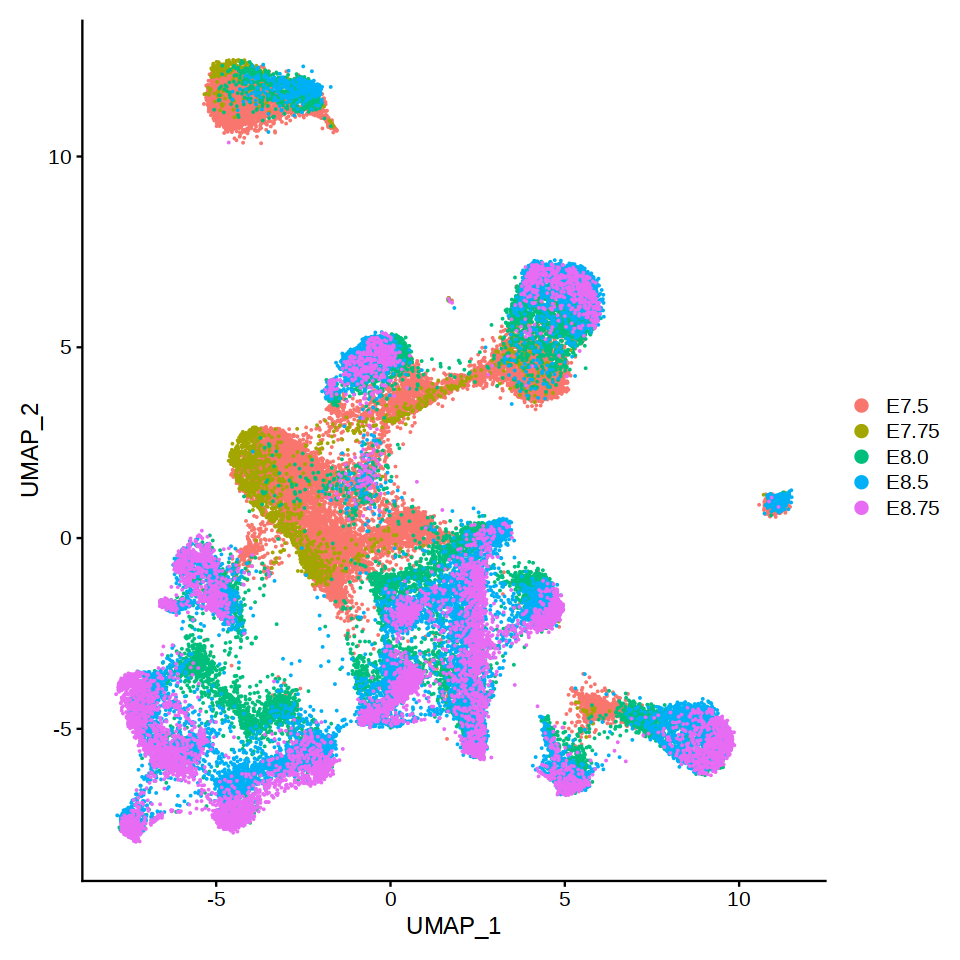

In [26]:
# Plot
atlas.atac <- RunUMAP(atlas.atac, reduction = "lsi", dims = 2:40, verbose=FALSE)
options(repr.plot.width=8, repr.plot.height=8)
p1 = DimPlot(atlas.atac)
p1

# Regressing TF-IDF

In [6]:
############################
## In vivo atlas multiome ##
############################

# Extract counts
atlas.counts = atlas.peakmatrix@assays@data$PeakMatrix
rownames(atlas.counts) = rownames(atlas.peakmatrix)

# create object
atlas.atac <- CreateSeuratObject(counts = atlas.counts, assay = "peaks")

# compute LSI
atlas.atac <- FindTopFeatures(atlas.atac, min.cutoff = "q85")
atlas.atac
atlas.atac <- RunTFIDF(atlas.atac)

An object of class Seurat 
192251 features across 45887 samples within 1 assay 
Active assay: peaks (192251 features, 28838 variable features)

Performing TF-IDF normalization



In [7]:
dim(atlas.atac@assays$peaks@data)

[1] 192251  45887

In [8]:
regression = altas_metadata[,c('nFrags_atac', 'TSSEnrichment_atac', 'NucleosomeRatio_atac')]

In [76]:
features = match(atlas.atac@assays$peaks@var.features, rownames(atlas.atac))
start <- Sys.time()
tdidf.regressed = RegressOutMatrix(mtx = atlas.atac@assays$peaks@data[features[0:3000],],  # [atlas.atac@assays$peaks@var.features,]
                                    covariates = regression,
                                    verbose=TRUE,
                                    ncores = 16)
print( Sys.time() - start )

Time difference of 2.797878 mins


In [79]:
features = match(atlas.atac@assays$peaks@var.features, rownames(atlas.atac))
start <- Sys.time()
tdidf.regressed = RegressOutMatrix(mtx = atlas.atac@assays$peaks@data[features[0:1000],],  # [atlas.atac@assays$peaks@var.features,]
                                    covariates = regression,
                                    verbose=TRUE,
                                    ncores = 1)
print( Sys.time() - start )

Time difference of 3.226282 mins


In [28]:
regression = altas_metadata[,c('nFrags_atac')]

In [77]:
features = match(atlas.atac@assays$peaks@var.features, rownames(atlas.atac))
start <- Sys.time()
tdidf.regressed = RegressOutMatrix(mtx = atlas.atac@assays$peaks@data[features[0:1000],],  # [atlas.atac@assays$peaks@var.features,]
                                    covariates = regression,
                                    verbose=TRUE,
                                    ncores = 16)
print( Sys.time() - start )

Time difference of 31.38973 secs


In [9]:
# for 3000 features, split by batches of 1000
features = match(atlas.atac@assays$peaks@var.features, rownames(atlas.atac))
start <- Sys.time()
tdidf.regressed.list = mclapply(1:1, function(x){
    start = (x-1)*1000
    end = start+999
    
    tdidf.regressed = RegressOutMatrix(mtx = atlas.atac@assays$peaks@data[features[start:end],],  # [atlas.atac@assays$peaks@var.features,]
                                    covariates = regression,
                                    verbose=TRUE,
                                    ncores = 16)
    return(round(tdidf.regressed,3))
    
}, mc.cores=1)
print( Sys.time() - start )


Time difference of 31.05534 secs


In [14]:
# for 3000 features, split by batches of 1000
features = match(atlas.atac@assays$peaks@var.features, rownames(atlas.atac))
start <- Sys.time()
tdidf.regressed.list = mclapply(1:28, function(x){
    start = (x-1)*1000
    end = start+999
    if(end>length(features)){end = length(features)}
    tdidf.regressed = RegressOutMatrix(mtx = atlas.atac@assays$peaks@data[features[start:end],],  # [atlas.atac@assays$peaks@var.features,]
                                    covariates = regression,
                                    verbose=TRUE,
                                    ncores = 5)
    return(round(tdidf.regressed,3))
}, mc.cores=5)
print( Sys.time() - start )


Time difference of 5.854108 mins


In [92]:
length(features)

[1] 28838

In [87]:
length(features)

[1] 28838

In [ ]:
atlas.atac2 = atlas.atac
atlas.atac2@assays$peaks@data = as(tdidf.regressed, "sparseMatrix")

In [ ]:
atlas.atac2 <- RunSVD(atlas.atac2, n = 40)
# Plot
atlas.atac2 <- RunUMAP(atlas.atac2, reduction = "lsi", dims = 2:40, verbose=FALSE)
options(repr.plot.width=8, repr.plot.height=8)
p2 = DimPlot(atlas.atac2)
p2